In [232]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../../tmp_data/merged_part_1.csv")
pd.set_option('display.max_columns', None)

In [233]:
df = df.drop(columns =
    [
        "ceiling_height",
        "metro_minutes",
        "metro_walking",
        "total_area",
        "living_area",
        "kitchen_area",
        "price",
        "utilities_amount",
        "utilities_included",
        "prepayment_months",
        "is_long_rental_term",
    ]
)

In [234]:
## Комнаты

df["types_room"] = df["Количество комнат"].str.replace(r"[^\D]", "", regex=True)
df["types_room"] = df["types_room"].str.replace(",", "").str.strip()
df["types_room"] = df["types_room"].replace('', pd.NA)

df["rooms_count_num"] = pd.to_numeric(df["rooms_count"], errors='coerce')

df["rooms_count_num"] = df["rooms_count_num"].fillna(
    df.apply(lambda x: max(1, round(
        (x['total_area'] / 22 + 
         (x['living_area'] / 15 if pd.notna(x['living_area']) else x['total_area'] / 25) +
         (x['kitchen_area'] / 8 if pd.notna(x['kitchen_area']) else x['total_area'] / 30)
        ) / 3 - 0.5
    )) if pd.notna(x['total_area']) else np.nan, axis=1)
)

def check_isolated_room(types_room, rooms_count):
    rooms_count_num = float(rooms_count) if rooms_count not in [None, 'nan', ''] else np.nan
    
    if pd.isna(types_room):
        return 0 if (rooms_count_num == 1) else None
    if rooms_count_num == 2 and pd.notna(types_room) and 'Оба варианта' in str(types_room):
        return 0
    if pd.notna(types_room) and ('Изолированная' in str(types_room) or 'Оба варианта' in str(types_room)):
        return 1
    return 0

def check_adjacent_room(types_room, rooms_count):
    rooms_count_num = float(rooms_count) if rooms_count not in [None, 'nan', ''] else np.nan
    
    if pd.isna(types_room):
        return 0 if rooms_count_num == 1 else None
    if rooms_count_num == 1:
        return 0
    if rooms_count_num == 2 and pd.notna(types_room) and 'Оба варианта' in str(types_room):
        return 1
    if pd.notna(types_room) and ('Смежная' in str(types_room) or 'Оба варианта' in str(types_room)):
        return 1
    return 0



df["rooms_count_str"] = df["rooms_count_num"].astype(str)

df['rooms_count'] = df['rooms_count_num']

df['is_isolated'] = df.apply(lambda row: check_isolated_room(row['types_room'], row['rooms_count_str']), axis=1)
df['is_adjacent'] = df.apply(lambda row: check_adjacent_room(row['types_room'], row['rooms_count_str']), axis=1)

df = df.drop(columns=['rooms_count_num', 'rooms_count_str'])

KeyError: 'total_area'

In [ ]:
## Дом



#df["house_tipe"].fillna

In [ ]:
## Парковка

# df["parking"].fillna

In [ ]:
## Ремонт

# df["renovation"].fillna

In [ ]:
## Балкон

# df['is_loggia'].fillna
# df['is_balcony'].fillna

In [ ]:
## Окна

# df['view_of_courtyard'].fillna
# df['view_of_street'].fillna

In [ ]:
## Санузел

df['combined_bathroom_count'] = np.where(df['combined_bathroom_count'].isna() & df['renovation'].isin([2, 3]), 1, np.where(df['combined_bathroom_count'].isna() & ~df['renovation'].isin([2, 3]), 0, df['combined_bathroom_count']))
df['separate_bathroom_count'] = np.where(df['separate_bathroom_count'].isna() & df['renovation'].isin([0, 1]), 1, np.where(df['separate_bathroom_count'].isna() & ~df['renovation'].isin([0, 1]), 0, df['separate_bathroom_count']))

In [ ]:
## Можно с детьми/животными

df['is_child'] = df['is_child'].fillna(0).astype(int)
df['is_pet'] = df['is_pet'].fillna(0).astype(int)

In [ ]:
## Дополнительно

df['room_furniture'] = df['room_furniture'].fillna(1).astype(int)
df['kitchen_furniture'] = df['kitchen_furniture'].fillna(1).astype(int)
df['bath'] = df['bath'].fillna(1).astype(int)
df['shower_cabin'] = np.where(df['shower_cabin'].isna() & df['renovation'].isin([3]), 1, np.where(df['shower_cabin'].isna() & ~df['renovation'].isin([3]), 0, df['shower_cabin']))
df['washing_machine'] = df['washing_machine'].fillna(1).astype(int)
df['air_conditioner'] = np.where(df['air_conditioner'].isna() & df['renovation'].isin([3]), 1, np.where(df['air_conditioner'].isna() & ~df['renovation'].isin([3]), 0, df['air_conditioner']))
df['dishwasher'] = np.where(df['dishwasher'].isna() & df['renovation'].isin([3]), 1, np.where(df['dishwasher'].isna() & ~df['renovation'].isin([3]), 0, df['dishwasher']))
df['tv'] = np.where(df['tv'].isna() & df['renovation'].isin([1, 2, 3]), 1, np.where(df['tv'].isna() & ~df['renovation'].isin([1, 2, 3]), 0, df['tv']))
df['fridge'] = df['fridge'].fillna(1).astype(int)
df['internet'] = df['internet'].fillna(1).astype(int)
df['telephone'] = df['telephone'].fillna(0).astype(int)

In [ ]:
## Лифт 

df['count_passenger_lift'] = df['count_passenger_lift'].apply(lambda x: np.nan if not pd.isna(x) and x > 10 else x)
df['count_freight_lift'] = df['count_freight_lift'].apply(lambda x: np.nan if not pd.isna(x) and x > 10 else x)

df['count_passenger_lift'] = df['count_passenger_lift'].fillna(df.apply(lambda x: 0 if x['house_floor'] <= 5 else 1, axis=1))
df['count_freight_lift'] = df['count_freight_lift'].fillna(df.apply(lambda x: 1 if x['house_floor'] > 16 or (10 <= x['house_floor'] <= 16 and x['house_type'] in [5, 8, 9]) else 0, axis=1))
    


In [ ]:
## Мусоропровод

def fill_garbage_chute(row):
    house_type = row['house_type']
    house_floor = row['house_floor']
    has_lift = row['count_passenger_lift'] > 0 or row['count_freight_lift'] > 0
    
    if pd.isna(house_type):
        return np.nan
    
    house_type = int(house_type)  # конвертируем float в int

    if house_type in [0, 1]:  # Панельный, Блочный
        return 1 if house_floor >= 9 else 0
    
    elif house_type in [2, 3]:  # Щитовой, Деревянный
        return 0

    elif house_type == 4:  # Газобетонный
        return 1 if (house_floor >= 12 and has_lift) else 0
    
    elif house_type == 5:  # Кирпичный
        return 1 if house_floor >= 5 else 0
    
    elif house_type == 6:  # Сталинский
        return 1 if house_floor > 10 else 0
    
    elif house_type == 7:  # Старый фонд
        return 0
    
    elif house_type == 8:  # Монолитно-кирпичный
        return 1 if (house_floor >= 17 and has_lift) else 0
    
    # Монолитные
    elif house_type == 9:  # Монолитный
        return 0
    
    else:
        return np.nan

# Применяем функцию
df['is_garbage_chute'] = df.apply(fill_garbage_chute, axis=1)

In [ ]:
missing_data = pd.DataFrame({
    'Колонка': df.columns,
    'Тип': df.dtypes.values,
    'Непустых': df.count().values,
    'Всего_записей': len(df),
    'Пропуски': df.isnull().sum().values,
    'Пропуски_%': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Пропуски_%', ascending=False)

print("Колонки с наибольшим количеством пропусков:")
print(missing_data.head(25).to_string(index=False))

Колонки с наибольшим количеством пропусков:
            Колонка     Тип  Непустых  Всего_записей  Пропуски  Пропуски_%
         types_room     str      9004          22615     13611       60.19
            parking float64      9606          22615     13009       57.52
     ceiling_height float64     10937          22615     11678       51.64
      count_balcony float64     15061          22615      7554       33.40
       count_loggia float64     15061          22615      7554       33.40
     view_of_street float64     16227          22615      6388       28.25
  view_of_courtyard float64     16227          22615      6388       28.25
       kitchen_area float64     17476          22615      5139       22.72
        is_adjacent float64     17545          22615      5070       22.42
        is_isolated float64     17545          22615      5070       22.42
         house_type float64     18914          22615      3701       16.37
   is_garbage_chute float64     18914          22615    

In [ ]:
df["rooms_count"].info()

<class 'pandas.Series'>
RangeIndex: 22615 entries, 0 to 22614
Series name: rooms_count
Non-Null Count  Dtype  
--------------  -----  
22615 non-null  float64
dtypes: float64(1)
memory usage: 176.8 KB


In [ ]:
df

,id,ceiling_height,metro_minutes,metro_walking,total_area,living_area,kitchen_area,price,utilities_amount,utilities_included,prepayment_months,is_long_rental_term,Количество комнат,rooms_count,floor,house_floor,house_type,parking,renovation,count_loggia,count_balcony,view_of_courtyard,view_of_street,combined_bathroom_count,separate_bathroom_count,is_child,is_pet,room_furniture,kitchen_furniture,bath,shower_cabin,washing_machine,air_conditioner,dishwasher,tv,fridge,internet,telephone,count_passenger_lift,count_freight_lift,is_garbage_chute,types_room,is_isolated,is_adjacent
0,271271157,3.00,9,1,200.0,20.0,NaN,500000.0,0.0,1,1.0,1,4,4.0,5,16,9.0,4.0,3.0,NaN,NaN,NaN,NaN,1.0,0.0,1,1,1,1,1,1.0,1,1.0,1.0,1.0,1,1,1,4.0,1.0,0.0,NaN,NaN,NaN
1,271634126,3.50,8,1,198.0,95.0,18.0,500000.0,0.0,1,1.0,1,4,4.0,5,16,8.0,4.0,3.0,NaN,NaN,1.0,1.0,2.0,1.0,1,0,1,1,1,1.0,1,1.0,1.0,1.0,1,1,0,1.0,1.0,0.0,NaN,NaN,NaN
2,271173086,3.20,7,1,200.0,116.0,4.0,500000.0,0.0,1,1.0,1,"4, Оба варианта",4.0,5,16,NaN,4.0,2.0,NaN,NaN,1.0,1.0,3.0,0.0,1,0,1,1,1,1.0,1,1.0,1.0,1.0,1,1,1,1.0,0.0,NaN,Оба варианта,1.0,1.0
3,272197456,3.20,3,1,170.0,95.0,17.0,400000.0,0.0,1,1.0,1,"4, Оба варианта",4.0,5,6,NaN,4.0,2.0,NaN,NaN,1.0,1.0,3.0,0.0,0,1,1,1,1,1.0,1,1.0,1.0,1.0,1,1,1,1.0,0.0,NaN,Оба варианта,1.0,1.0
4,273614615,3.90,7,1,58.0,38.0,5.0,225000.0,0.0,1,1.0,1,2,2.0,12,26,0.0,NaN,2.0,NaN,NaN,1.0,1.0,2.0,0.0,0,0,1,1,1,1.0,1,0.0,1.0,1.0,1,1,0,1.0,1.0,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22610,215565511,NaN,8,1,35.0,16.4,8.0,42000.0,0.0,1,1.0,1,NaN,1.0,10,14,NaN,NaN,2.0,0.0,1.0,NaN,NaN,1.0,0.0,0,0,1,1,1,0.0,1,1.0,0.0,0.0,1,1,0,1.0,1.0,NaN,NaN,0.0,0.0
22611,274654844,NaN,7,1,38.7,16.5,11.0,45000.0,0.0,1,1.0,1,1,1.0,5,18,9.0,NaN,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0,1,1,1,0.0,1,0.0,0.0,1.0,1,0,0,1.0,1.0,0.0,NaN,0.0,0.0
22612,268679909,NaN,6,1,43.1,NaN,NaN,50000.0,0.0,1,1.0,1,"2, Оба варианта",2.0,5,5,5.0,NaN,3.0,0.0,1.0,1.0,1.0,1.0,0.0,1,0,0,1,0,1.0,1,1.0,0.0,0.0,1,1,0,0.0,0.0,1.0,Оба варианта,0.0,1.0
22613,274807525,2.65,11,1,52.5,10.0,NaN,55000.0,0.0,1,2.0,1,2,2.0,8,23,9.0,0.0,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0,0,1,1,1,0.0,1,1.0,1.0,0.0,1,0,0,3.0,0.0,0.0,NaN,NaN,NaN


In [ ]:
df.to_csv('../../tmp_data/vanya_processed_part_2.csv', index=False)

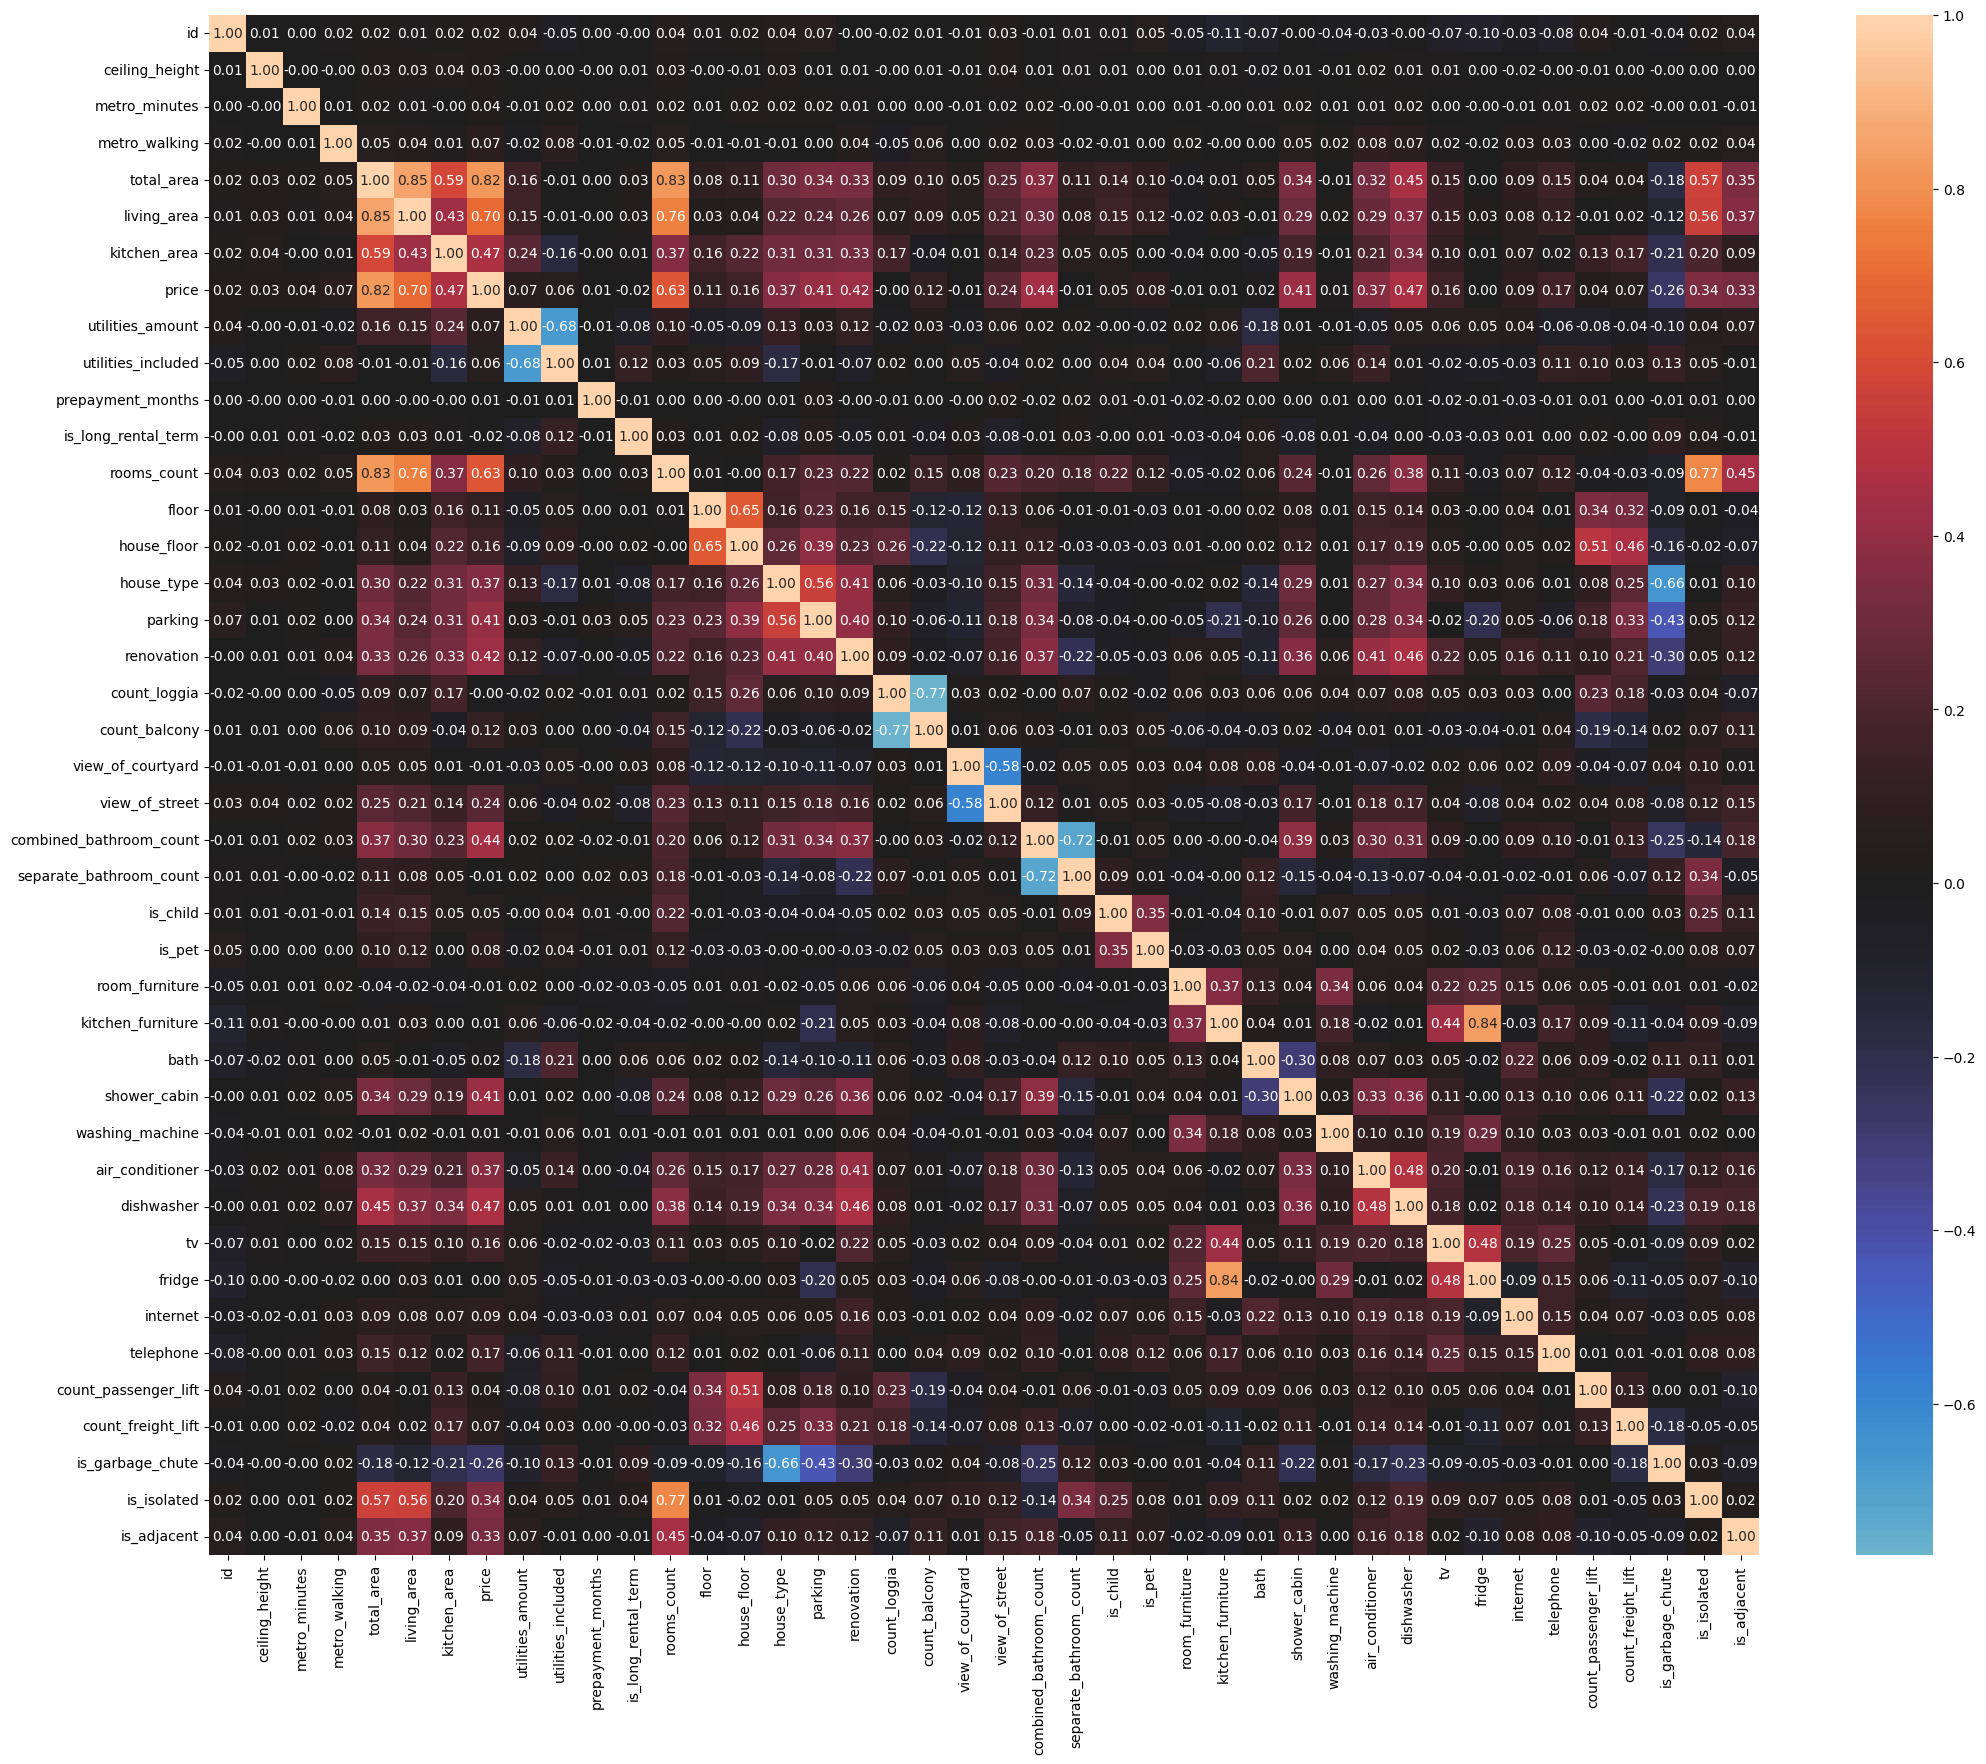

In [ ]:
plt.figure(figsize=(25, 20))
sns.heatmap(df.corr(numeric_only = True), annot = True, center = 0, fmt = ".2f");